# Comprehensive Analysis of MMLLM Benchmark Results

This notebook provides a comprehensive analysis of the experimental results from multiple runs of the MMLLM (Multimodal Language Learning Model) benchmarking framework. 

## Overview

We will analyze:
1. **Individual Run Performance**: Comparing stateless vs stateful configurations
2. **Dataset-Specific Analysis**: Performance breakdown by dataset
3. **Cross-Run Analysis**: Common failure patterns and mismatches
4. **Report Integration**: Insights from JSON reports
5. **Summary Visualizations**: Complete story dashboard

The data comes from the `results/` folder which contains multiple experimental runs with CSV results and JSON reports.

## 1. Setup Environment and Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import os
import json
import glob
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up matplotlib style
plt.style.use('default')
sns.set_palette("husl")

# Configure plot settings
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Define base paths
RESULTS_PATH = Path("../results")
print(f"Results path: {RESULTS_PATH.absolute()}")
print(f"Results path exists: {RESULTS_PATH.exists()}")

# Function to safely load JSON files
def load_json_report(file_path):
    """Load JSON report file safely"""
    try:
        with open(file_path, 'r') as f:
            return json.load(f)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

print("Setup complete!")

Results path: /dss/dsshome1/02/go34yuf2/mmllm/vis/../results
Results path exists: True
Setup complete!


## 2. Load and Explore Data Structure

Let's scan the results folder structure and understand the available data.

In [3]:
# Discover all CSV and JSON files in the results directory
def discover_result_files():
    """Discover all CSV and JSON files in the results directory"""
    csv_files = []
    json_files = []
    
    for root, dirs, files in os.walk(RESULTS_PATH):
        for file in files:
            file_path = Path(root) / file
            if file.endswith('.csv'):
                csv_files.append(file_path)
            elif file.endswith('.json'):
                json_files.append(file_path)
    
    return csv_files, json_files

csv_files, json_files = discover_result_files()

print("Discovered files:")
print(f"CSV files: {len(csv_files)}")
for csv_file in csv_files:
    print(f"  - {csv_file}")

print(f"\nJSON files: {len(json_files)}")
for json_file in json_files:
    print(f"  - {json_file}")

# Load and examine the structure of the first CSV file
if csv_files:
    sample_csv = csv_files[0]
    print(f"\nExamining CSV structure from: {sample_csv}")
    
    # Load a sample of the CSV to understand structure
    sample_df = pd.read_csv(sample_csv)
    print(f"Shape: {sample_df.shape}")
    print(f"Columns: {list(sample_df.columns)}")
    print("\nFirst few rows:")
    print(sample_df.head(3))
    
    print("\nData types:")
    print(sample_df.dtypes)

Discovered files:
CSV files: 4
  - ../results/tree-vs-no-tree/tree/benchmark_results_20250720_130945.csv
  - ../results/tree-vs-no-tree/no-tree/benchmark_results_20250720_130908.csv
  - ../results/stateless-vs-statefull/stateless/benchmark_results_20250720_121356.csv
  - ../results/stateless-vs-statefull/statefull/benchmark_results_20250720_125011.csv

JSON files: 4
  - ../results/tree-vs-no-tree/tree/benchmark_report_20250720_130945.json
  - ../results/tree-vs-no-tree/no-tree/benchmark_report_20250720_130908.json
  - ../results/stateless-vs-statefull/stateless/benchmark_report_20250720_121356.json
  - ../results/stateless-vs-statefull/statefull/benchmark_report_20250720_125011.json

Examining CSV structure from: ../results/tree-vs-no-tree/tree/benchmark_results_20250720_130945.csv
Shape: (235, 38)
Columns: ['run_name', 'timestamp', 'dataset_name', 'ocr_module', 'episode_id', 'goal', 'episode_success_rate', 'episode_step_accuracy', 'episode_total_steps', 'episode_steps_completed', 'epi

In [4]:
# Load all CSV data into a combined dataframe
def load_all_csv_data():
    """Load all CSV files and combine them with run identification"""
    all_data = []
    
    for csv_file in csv_files:
        try:
            df = pd.read_csv(csv_file)
            
            # Extract run information from path
            path_parts = csv_file.parts
            if 'stateless-vs-statefull' in path_parts:
                run_type = 'stateless-vs-statefull'
                if 'stateless' in path_parts:
                    run_config = 'stateless'
                elif 'statefull' in path_parts:
                    run_config = 'stateful'
            elif 'tree-vs-no-tree' in path_parts:
                run_type = 'tree-vs-no-tree'
                if 'tree' in path_parts:
                    run_config = 'tree'
                elif 'no-tree' in path_parts:
                    run_config = 'no-tree'
            else:
                run_type = 'unknown'
                run_config = 'unknown'
            
            # Add metadata columns
            df['run_type'] = run_type
            df['run_config'] = run_config
            df['file_path'] = str(csv_file)
            
            all_data.append(df)
            print(f"Loaded {len(df)} rows from {csv_file}")
            
        except Exception as e:
            print(f"Error loading {csv_file}: {e}")
    
    if all_data:
        combined_df = pd.concat(all_data, ignore_index=True)
        print(f"\nCombined dataset shape: {combined_df.shape}")
        return combined_df
    else:
        print("No data loaded!")
        return pd.DataFrame()

# Load all data
combined_data = load_all_csv_data()

# Show run configurations available
if not combined_data.empty:
    print("\nAvailable run configurations:")
    run_summary = combined_data.groupby(['run_type', 'run_config']).size().reset_index(name='count')
    print(run_summary)

Loaded 235 rows from ../results/tree-vs-no-tree/tree/benchmark_results_20250720_130945.csv
Loaded 237 rows from ../results/tree-vs-no-tree/no-tree/benchmark_results_20250720_130908.csv
Loaded 236 rows from ../results/stateless-vs-statefull/stateless/benchmark_results_20250720_121356.csv
Loaded 233 rows from ../results/stateless-vs-statefull/statefull/benchmark_results_20250720_125011.csv

Combined dataset shape: (941, 41)

Available run configurations:
                 run_type run_config  count
0  stateless-vs-statefull   stateful    233
1  stateless-vs-statefull  stateless    236
2         tree-vs-no-tree    no-tree    237
3         tree-vs-no-tree       tree    235


## 3. Individual Run Analysis - Stateless vs Stateful

Now let's compare the performance between stateless and stateful configurations.

Stateless vs Stateful data shape: (469, 41)


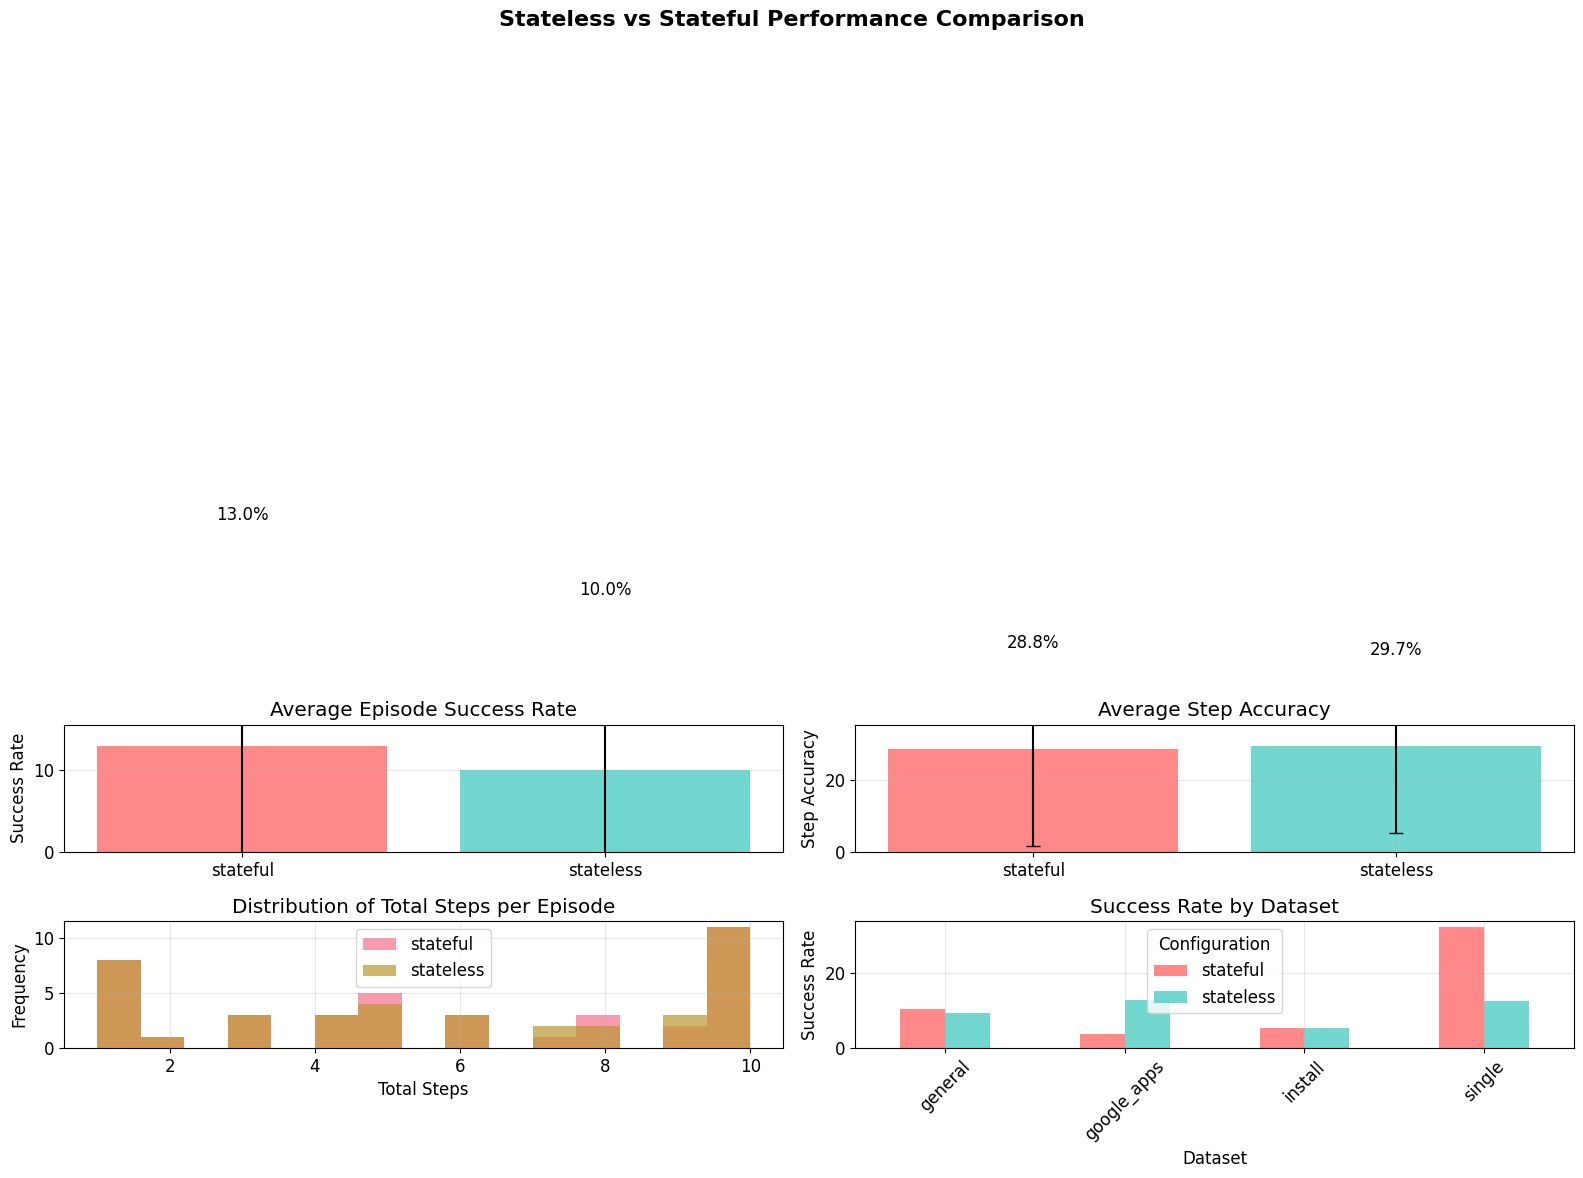


STATELESS VS STATEFUL SUMMARY

STATEFUL Configuration:
  Average Success Rate: 12.99%
  Average Step Accuracy: 28.85%
  Average Total Steps: 5.8
  Average Completed Steps: 1.5
  Total Episodes: 40

STATELESS Configuration:
  Average Success Rate: 10.03%
  Average Step Accuracy: 29.66%
  Average Total Steps: 5.9
  Average Completed Steps: 1.9
  Total Episodes: 40


In [5]:
# Filter data for stateless vs stateful comparison
stateless_stateful_data = combined_data[combined_data['run_type'] == 'stateless-vs-statefull'].copy()

if not stateless_stateful_data.empty:
    print(f"Stateless vs Stateful data shape: {stateless_stateful_data.shape}")
    
    # Calculate episode-level metrics
    episode_metrics = stateless_stateful_data.groupby(['run_config', 'episode_id']).agg({
        'episode_success_rate': 'first',
        'episode_step_accuracy': 'first', 
        'episode_total_steps': 'first',
        'episode_steps_completed': 'first',
        'dataset_name': 'first'
    }).reset_index()
    
    # Create comparison visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Stateless vs Stateful Performance Comparison', fontsize=16, fontweight='bold')
    
    # 1. Success Rate Comparison
    success_by_config = episode_metrics.groupby('run_config')['episode_success_rate'].agg(['mean', 'std']).reset_index()
    ax1 = axes[0, 0]
    bars1 = ax1.bar(success_by_config['run_config'], success_by_config['mean'], 
                   yerr=success_by_config['std'], capsize=5, 
                   color=['#FF6B6B', '#4ECDC4'], alpha=0.8)
    ax1.set_title('Average Episode Success Rate')
    ax1.set_ylabel('Success Rate')
    ax1.set_ylim(0, max(success_by_config['mean']) * 1.2)
    for i, bar in enumerate(bars1):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + success_by_config['std'].iloc[i],
                f'{height:.1f}%', ha='center', va='bottom')
    
    # 2. Step Accuracy Comparison
    accuracy_by_config = episode_metrics.groupby('run_config')['episode_step_accuracy'].agg(['mean', 'std']).reset_index()
    ax2 = axes[0, 1]
    bars2 = ax2.bar(accuracy_by_config['run_config'], accuracy_by_config['mean'], 
                   yerr=accuracy_by_config['std'], capsize=5,
                   color=['#FF6B6B', '#4ECDC4'], alpha=0.8)
    ax2.set_title('Average Step Accuracy')
    ax2.set_ylabel('Step Accuracy')
    ax2.set_ylim(0, max(accuracy_by_config['mean']) * 1.2)
    for i, bar in enumerate(bars2):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + accuracy_by_config['std'].iloc[i],
                f'{height:.1f}%', ha='center', va='bottom')
    
    # 3. Steps Distribution
    ax3 = axes[1, 0]
    for config in episode_metrics['run_config'].unique():
        config_data = episode_metrics[episode_metrics['run_config'] == config]
        ax3.hist(config_data['episode_total_steps'], alpha=0.7, label=config, bins=15)
    ax3.set_title('Distribution of Total Steps per Episode')
    ax3.set_xlabel('Total Steps')
    ax3.set_ylabel('Frequency')
    ax3.legend()
    
    # 4. Performance by Dataset
    ax4 = axes[1, 1]
    dataset_performance = episode_metrics.groupby(['dataset_name', 'run_config'])['episode_success_rate'].mean().unstack()
    dataset_performance.plot(kind='bar', ax=ax4, color=['#FF6B6B', '#4ECDC4'], alpha=0.8)
    ax4.set_title('Success Rate by Dataset')
    ax4.set_ylabel('Success Rate')
    ax4.set_xlabel('Dataset')
    ax4.legend(title='Configuration')
    ax4.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*50)
    print("STATELESS VS STATEFUL SUMMARY")
    print("="*50)
    for config in episode_metrics['run_config'].unique():
        config_data = episode_metrics[episode_metrics['run_config'] == config]
        print(f"\n{config.upper()} Configuration:")
        print(f"  Average Success Rate: {config_data['episode_success_rate'].mean():.2f}%")
        print(f"  Average Step Accuracy: {config_data['episode_step_accuracy'].mean():.2f}%")
        print(f"  Average Total Steps: {config_data['episode_total_steps'].mean():.1f}")
        print(f"  Average Completed Steps: {config_data['episode_steps_completed'].mean():.1f}")
        print(f"  Total Episodes: {len(config_data)}")

else:
    print("No stateless vs stateful data found!")

## 4. Dataset-Specific Performance Comparison

Let's analyze how different configurations perform across various datasets with detailed breakdowns.

Datasets found: ['general' 'google_apps' 'install' 'single']
Run configurations: [('stateless-vs-statefull', 'stateful'), ('stateless-vs-statefull', 'stateless'), ('tree-vs-no-tree', 'no-tree'), ('tree-vs-no-tree', 'tree')]


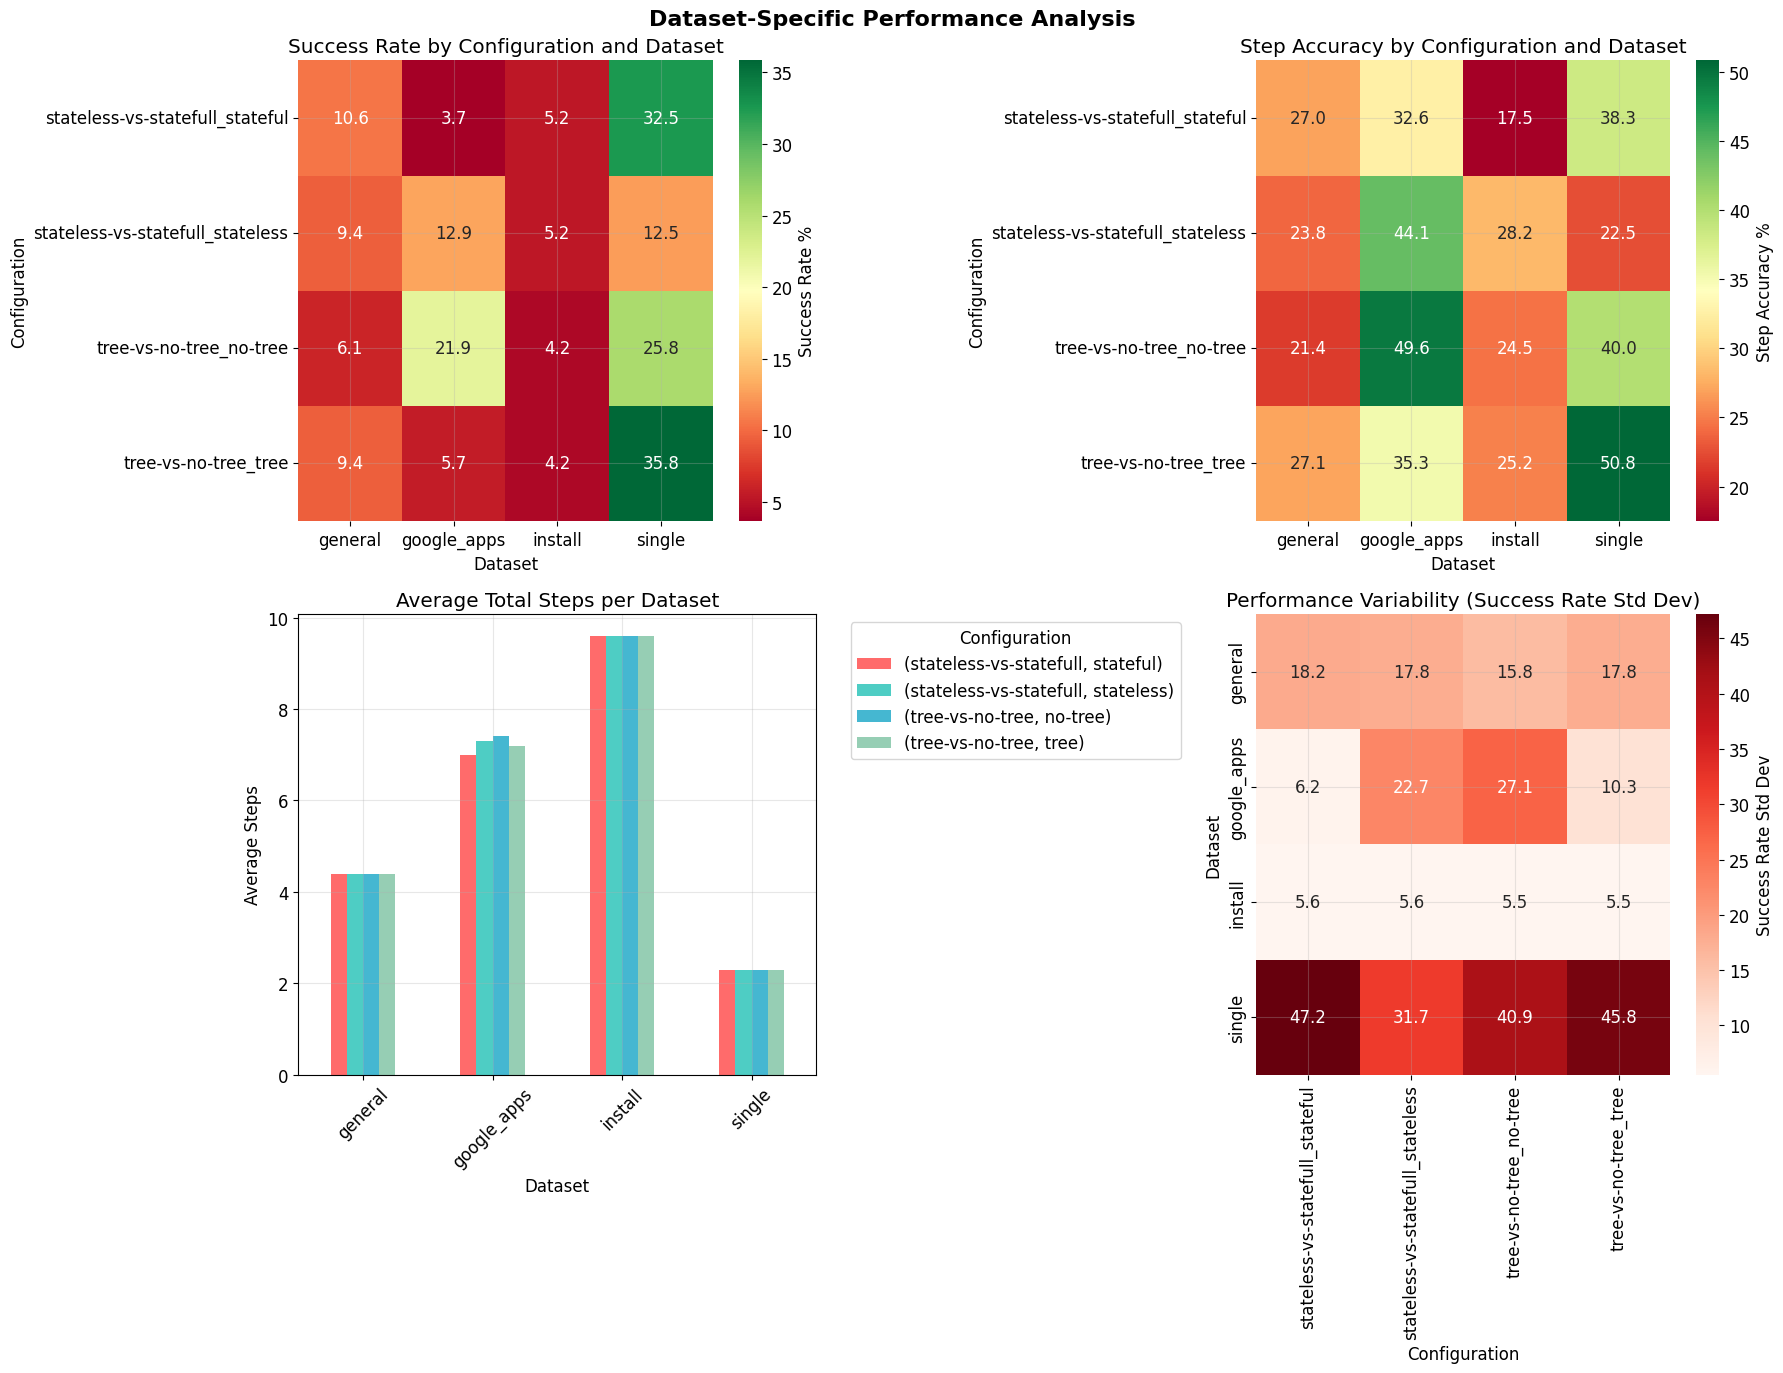


DETAILED DATASET PERFORMANCE STATISTICS
                                               episode_success_rate         \
                                                               mean    std   
run_type               run_config dataset_name                               
stateless-vs-statefull stateful   general                     10.56  18.23   
                                  google_apps                  3.67   6.18   
                                  install                      5.25   5.58   
                                  single                      32.50  47.21   
                       stateless  general                      9.44  17.77   
                                  google_apps                 12.92  22.69   
                                  install                      5.25   5.58   
                                  single                      12.50  31.73   
tree-vs-no-tree        no-tree    general                      6.11  15.81   
                       

In [6]:
# Create comprehensive dataset-specific analysis
if not combined_data.empty:
    # Get unique datasets across all runs
    datasets = combined_data['dataset_name'].unique()
    run_configs = combined_data.groupby(['run_type', 'run_config']).size().index.tolist()
    
    print(f"Datasets found: {datasets}")
    print(f"Run configurations: {run_configs}")
    
    # Create episode-level summary for all runs
    all_episode_metrics = combined_data.groupby(['run_type', 'run_config', 'dataset_name', 'episode_id']).agg({
        'episode_success_rate': 'first',
        'episode_step_accuracy': 'first',
        'episode_total_steps': 'first',
        'episode_steps_completed': 'first'
    }).reset_index()
    
    # Create a comprehensive heatmap
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    fig.suptitle('Dataset-Specific Performance Analysis', fontsize=16, fontweight='bold')
    
    # 1. Success Rate Heatmap
    ax1 = axes[0, 0]
    success_pivot = all_episode_metrics.groupby(['run_type', 'run_config', 'dataset_name'])['episode_success_rate'].mean().unstack(level='dataset_name')
    success_pivot.index = [f"{rt}_{rc}" for rt, rc in success_pivot.index]
    sns.heatmap(success_pivot, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax1, cbar_kws={'label': 'Success Rate %'})
    ax1.set_title('Success Rate by Configuration and Dataset')
    ax1.set_xlabel('Dataset')
    ax1.set_ylabel('Configuration')
    
    # 2. Step Accuracy Heatmap
    ax2 = axes[0, 1]
    accuracy_pivot = all_episode_metrics.groupby(['run_type', 'run_config', 'dataset_name'])['episode_step_accuracy'].mean().unstack(level='dataset_name')
    accuracy_pivot.index = [f"{rt}_{rc}" for rt, rc in accuracy_pivot.index]
    sns.heatmap(accuracy_pivot, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax2, cbar_kws={'label': 'Step Accuracy %'})
    ax2.set_title('Step Accuracy by Configuration and Dataset')
    ax2.set_xlabel('Dataset')
    ax2.set_ylabel('Configuration')
    
    # 3. Average Steps per Dataset
    ax3 = axes[1, 0]
    steps_by_dataset = all_episode_metrics.groupby(['dataset_name', 'run_type', 'run_config'])['episode_total_steps'].mean().unstack(level=['run_type', 'run_config'])
    steps_by_dataset.plot(kind='bar', ax=ax3, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
    ax3.set_title('Average Total Steps per Dataset')
    ax3.set_ylabel('Average Steps')
    ax3.set_xlabel('Dataset')
    ax3.legend(title='Configuration', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax3.tick_params(axis='x', rotation=45)
    
    # 4. Performance Variance by Dataset
    ax4 = axes[1, 1]
    variance_data = []
    for dataset in datasets:
        dataset_data = all_episode_metrics[all_episode_metrics['dataset_name'] == dataset]
        for (run_type, run_config), group in dataset_data.groupby(['run_type', 'run_config']):
            variance_data.append({
                'dataset': dataset,
                'config': f"{run_type}_{run_config}",
                'success_std': group['episode_success_rate'].std(),
                'accuracy_std': group['episode_step_accuracy'].std()
            })
    
    variance_df = pd.DataFrame(variance_data)
    if not variance_df.empty:
        variance_pivot = variance_df.pivot(index='dataset', columns='config', values='success_std')
        sns.heatmap(variance_pivot, annot=True, fmt='.1f', cmap='Reds', ax=ax4, cbar_kws={'label': 'Success Rate Std Dev'})
        ax4.set_title('Performance Variability (Success Rate Std Dev)')
        ax4.set_xlabel('Configuration')
        ax4.set_ylabel('Dataset')
    
    plt.tight_layout()
    plt.show()
    
    # Detailed statistics table
    print("\n" + "="*80)
    print("DETAILED DATASET PERFORMANCE STATISTICS")
    print("="*80)
    
    detailed_stats = all_episode_metrics.groupby(['run_type', 'run_config', 'dataset_name']).agg({
        'episode_success_rate': ['mean', 'std', 'count'],
        'episode_step_accuracy': ['mean', 'std'],
        'episode_total_steps': ['mean', 'std']
    }).round(2)
    
    print(detailed_stats)

else:
    print("No data available for analysis!")

## 5. Cross-Run Analysis - Common Failure Types

Now let's analyze common failure patterns across all runs to identify the most frequent issues.

Analyzing failure patterns...
Total steps: 941
Failed steps: 641
Successful steps: 300
Overall failure rate: 68.1%


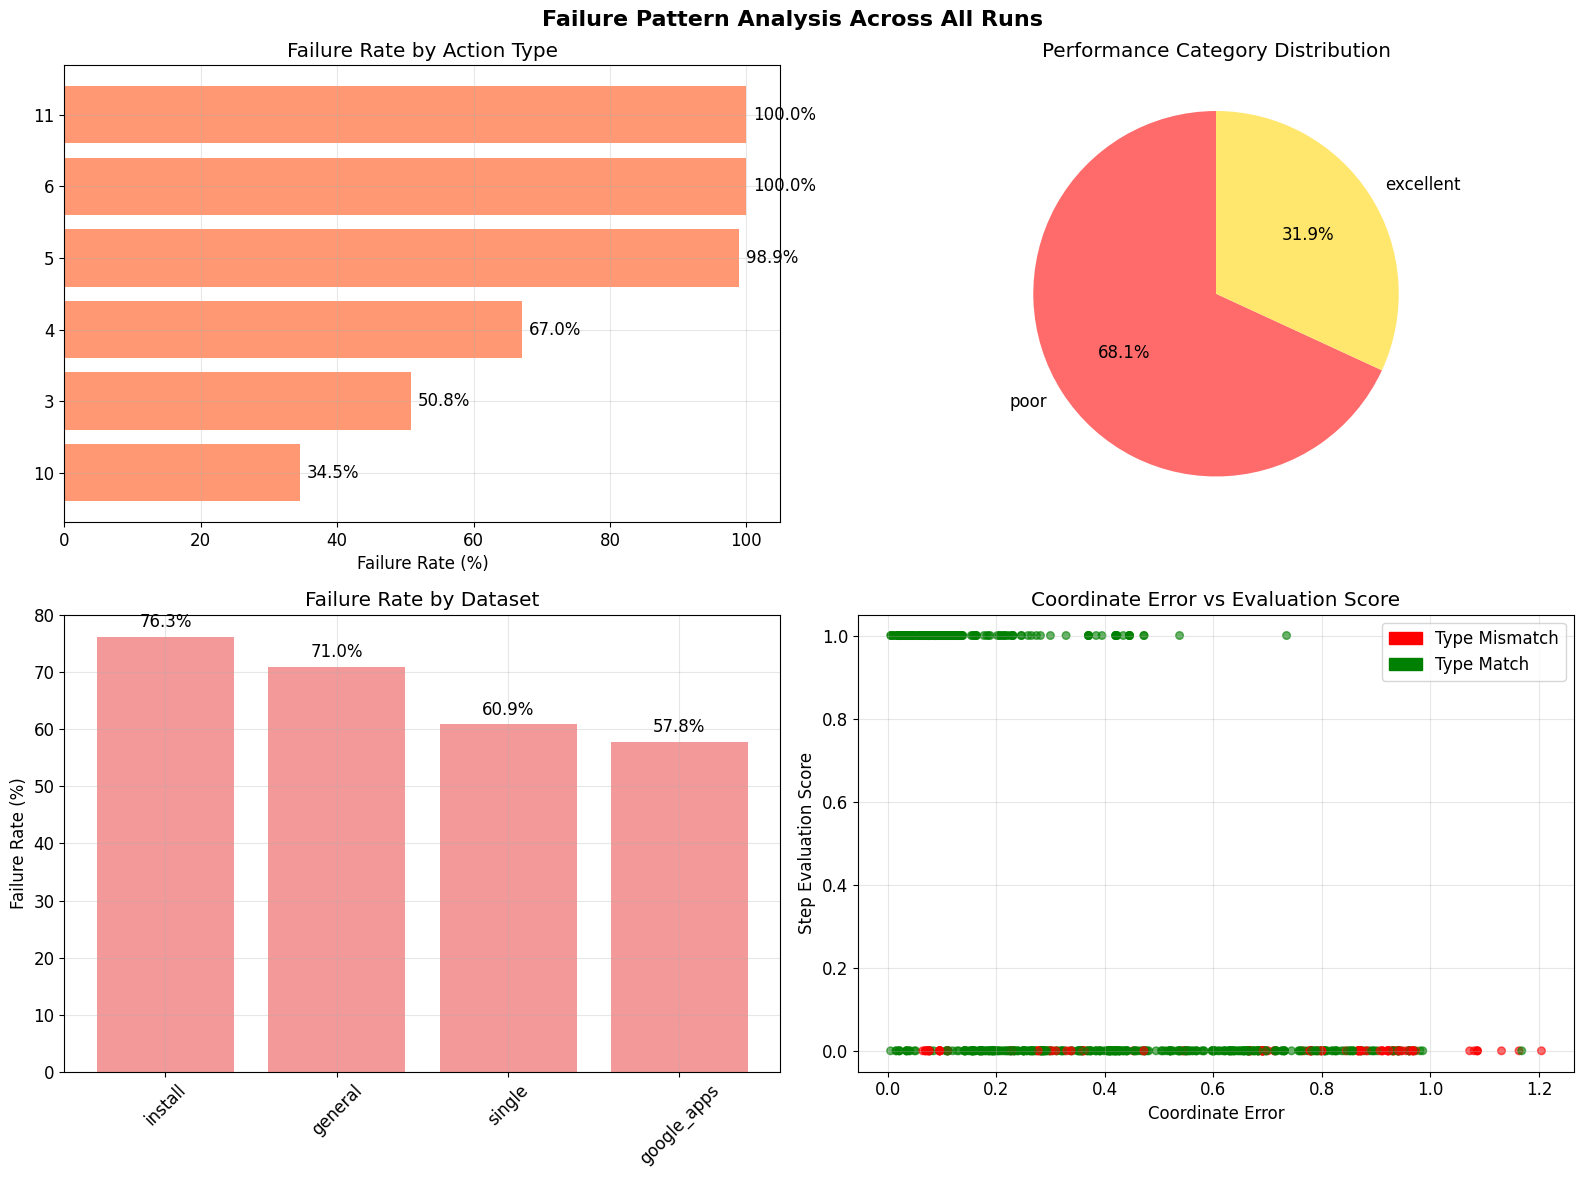


FAILURE ANALYSIS SUMMARY

Most problematic action types:
  6: 100.0% failure rate (21.0 total steps)
  11: 100.0% failure rate (2.0 total steps)
  5: 98.9% failure rate (95.0 total steps)

Most problematic datasets:
  install: 76.3% failure rate (384.0 total steps)
  general: 71.0% failure rate (176.0 total steps)
  single: 60.9% failure rate (92.0 total steps)

Performance categories:
  poor: 641 steps (68.1%)
  excellent: 300 steps (31.9%)


In [7]:
# Analyze failure patterns across all runs
if not combined_data.empty:
    # Create failure analysis based on available columns
    print("Analyzing failure patterns...")
    
    # Identify failed steps
    failed_steps = combined_data[combined_data['step_action_match'] == False].copy()
    successful_steps = combined_data[combined_data['step_action_match'] == True].copy()
    
    print(f"Total steps: {len(combined_data)}")
    print(f"Failed steps: {len(failed_steps)}")
    print(f"Successful steps: {len(successful_steps)}")
    print(f"Overall failure rate: {len(failed_steps)/len(combined_data)*100:.1f}%")
    
    # Create failure analysis visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Failure Pattern Analysis Across All Runs', fontsize=16, fontweight='bold')
    
    # 1. Failure rate by action type
    ax1 = axes[0, 0]
    action_failure = combined_data.groupby('model_action_type').agg({
        'step_action_match': ['count', 'sum']
    }).round(2)
    action_failure.columns = ['total', 'successful']
    action_failure['failure_rate'] = (1 - action_failure['successful'] / action_failure['total']) * 100
    action_failure = action_failure.sort_values('failure_rate', ascending=True)
    
    bars1 = ax1.barh(range(len(action_failure)), action_failure['failure_rate'], 
                    color='coral', alpha=0.8)
    ax1.set_yticks(range(len(action_failure)))
    ax1.set_yticklabels(action_failure.index)
    ax1.set_xlabel('Failure Rate (%)')
    ax1.set_title('Failure Rate by Action Type')
    
    # Add value labels
    for i, bar in enumerate(bars1):
        width = bar.get_width()
        ax1.text(width + 1, bar.get_y() + bar.get_height()/2, 
                f'{width:.1f}%', ha='left', va='center')
    
    # 2. Performance category distribution
    ax2 = axes[0, 1]
    perf_categories = combined_data['performance_category'].value_counts()
    colors = ['#FF6B6B', '#FFE66D', '#4ECDC4'][:len(perf_categories)]
    wedges, texts, autotexts = ax2.pie(perf_categories.values, labels=perf_categories.index, 
                                      autopct='%1.1f%%', colors=colors, startangle=90)
    ax2.set_title('Performance Category Distribution')
    
    # 3. Failure rate by dataset
    ax3 = axes[1, 0]
    dataset_failure = combined_data.groupby('dataset_name').agg({
        'step_action_match': ['count', 'sum']
    })
    dataset_failure.columns = ['total', 'successful']
    dataset_failure['failure_rate'] = (1 - dataset_failure['successful'] / dataset_failure['total']) * 100
    dataset_failure = dataset_failure.sort_values('failure_rate', ascending=False)
    
    bars3 = ax3.bar(range(len(dataset_failure)), dataset_failure['failure_rate'], 
                   color='lightcoral', alpha=0.8)
    ax3.set_xticks(range(len(dataset_failure)))
    ax3.set_xticklabels(dataset_failure.index, rotation=45)
    ax3.set_ylabel('Failure Rate (%)')
    ax3.set_title('Failure Rate by Dataset')
    
    # Add value labels
    for i, bar in enumerate(bars3):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom')
    
    # 4. Action type match vs coordination accuracy
    ax4 = axes[1, 1]
    coord_data = combined_data[combined_data['has_coordinate_data'] == True]
    if not coord_data.empty:
        # Create scatter plot of coordination errors vs action matches
        scatter_colors = ['red' if not match else 'green' for match in coord_data['step_action_type_match']]
        ax4.scatter(coord_data['coordinate_error'], coord_data['step_evaluation_score'], 
                   c=scatter_colors, alpha=0.6, s=30)
        ax4.set_xlabel('Coordinate Error')
        ax4.set_ylabel('Step Evaluation Score')
        ax4.set_title('Coordinate Error vs Evaluation Score')
        
        # Add legend
        red_patch = mpatches.Patch(color='red', label='Type Mismatch')
        green_patch = mpatches.Patch(color='green', label='Type Match')
        ax4.legend(handles=[red_patch, green_patch])
    else:
        ax4.text(0.5, 0.5, 'No coordinate data available', 
                ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title('Coordinate Error Analysis (No Data)')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed failure statistics
    print("\n" + "="*60)
    print("FAILURE ANALYSIS SUMMARY")
    print("="*60)
    
    print(f"\nMost problematic action types:")
    top_failing_actions = action_failure.nlargest(3, 'failure_rate')
    for action_type, row in top_failing_actions.iterrows():
        print(f"  {action_type}: {row['failure_rate']:.1f}% failure rate ({row['total']} total steps)")
    
    print(f"\nMost problematic datasets:")
    top_failing_datasets = dataset_failure.nlargest(3, 'failure_rate')
    for dataset, row in top_failing_datasets.iterrows():
        print(f"  {dataset}: {row['failure_rate']:.1f}% failure rate ({row['total']} total steps)")
    
    print(f"\nPerformance categories:")
    for category, count in perf_categories.items():
        percentage = count / len(combined_data) * 100
        print(f"  {category}: {count} steps ({percentage:.1f}%)")

else:
    print("No data available for failure analysis!")

## 6. Cross-Run Analysis - Dataset Mismatch Patterns

Let's analyze specific mismatch patterns per dataset to identify systematic issues.

Analyzing mismatch patterns per dataset...


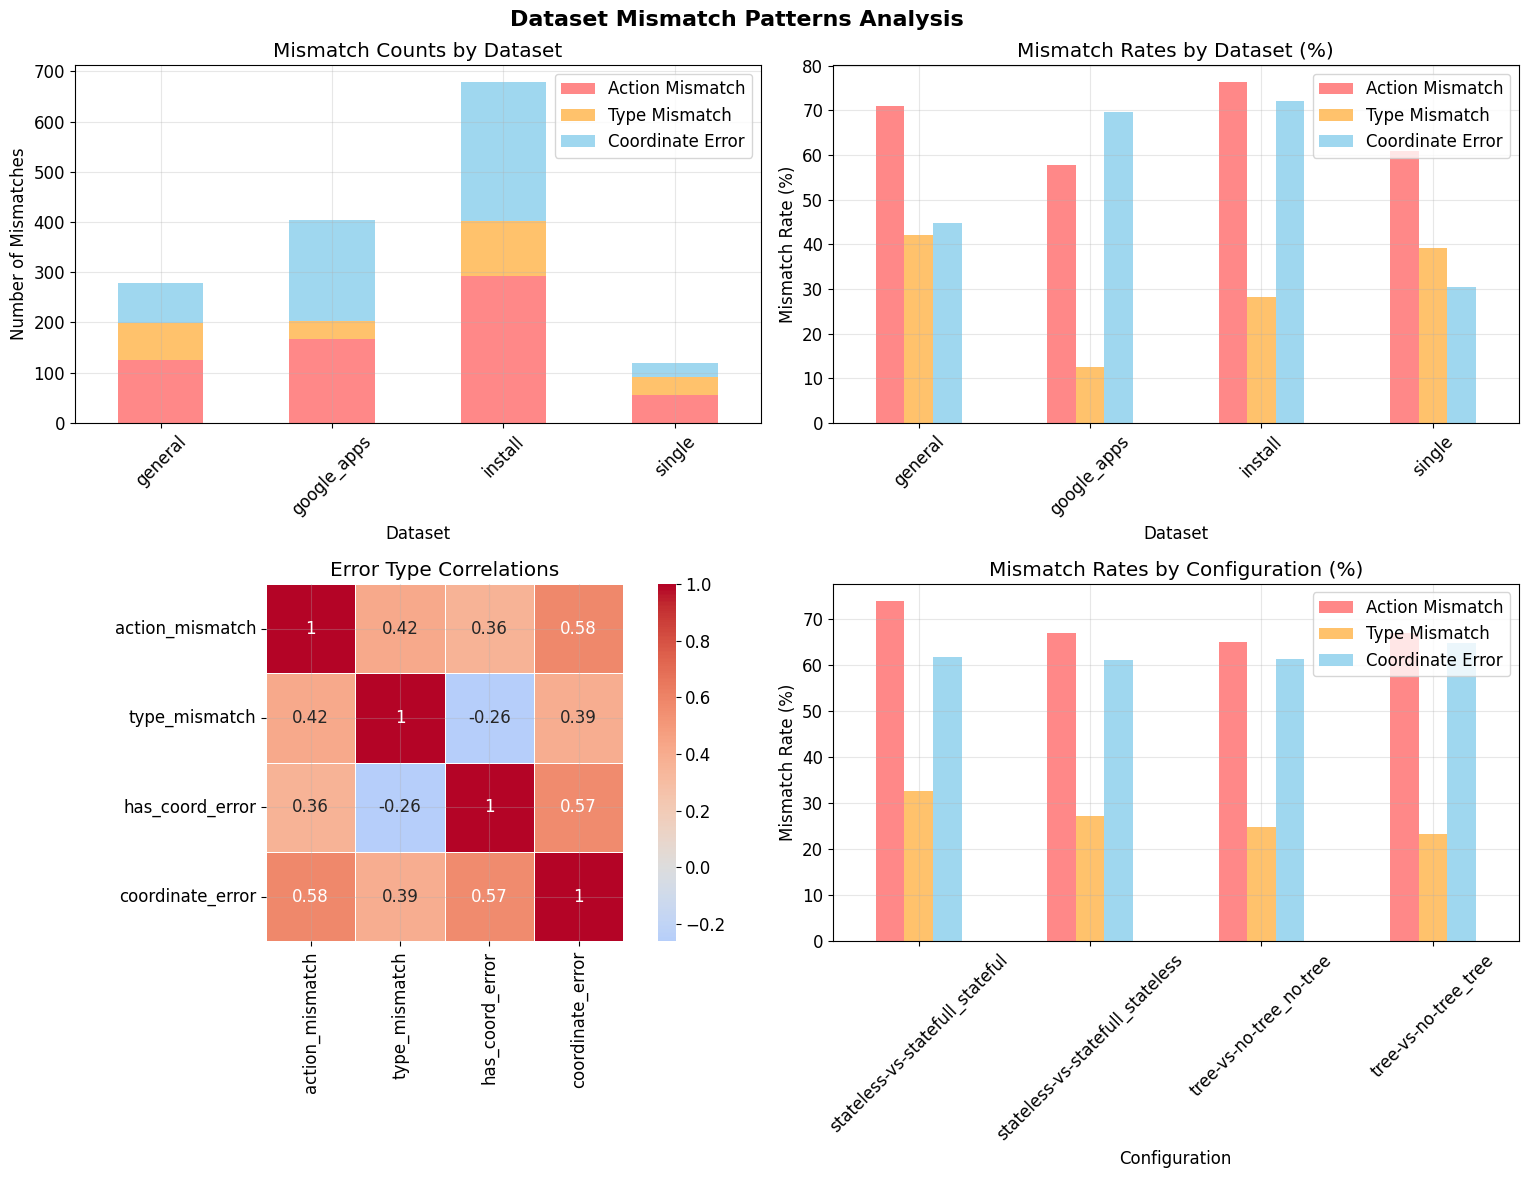


DATASET MISMATCH ANALYSIS

GENERAL Dataset:
  Total steps: 176
  Action mismatches: 125 (71.0%)
  Type mismatches: 74 (42.0%)
  Coordinate errors: 79 (44.9%)
  Average coordinate error: 0.360

GOOGLE_APPS Dataset:
  Total steps: 289
  Action mismatches: 167 (57.8%)
  Type mismatches: 36 (12.5%)
  Coordinate errors: 201 (69.6%)
  Average coordinate error: 0.333

INSTALL Dataset:
  Total steps: 384
  Action mismatches: 293 (76.3%)
  Type mismatches: 108 (28.1%)
  Coordinate errors: 277 (72.1%)
  Average coordinate error: 0.446

SINGLE Dataset:
  Total steps: 92
  Action mismatches: 56 (60.9%)
  Type mismatches: 36 (39.1%)
  Coordinate errors: 28 (30.4%)
  Average coordinate error: 0.318

MOST PROBLEMATIC COMBINATIONS

Top 5 most problematic dataset-configuration combinations:
  install + stateless-vs-statefull_stateful: 62.5% avg mismatch rate
  install + tree-vs-no-tree_no-tree: 58.3% avg mismatch rate
  install + stateless-vs-statefull_stateless: 57.3% avg mismatch rate
  install + tr

In [8]:
# Analyze mismatch patterns per dataset
if not combined_data.empty:
    print("Analyzing mismatch patterns per dataset...")
    
    # Create mismatch analysis
    mismatch_data = combined_data.copy()
    
    # Define mismatch types
    mismatch_data['action_mismatch'] = ~mismatch_data['step_action_match']
    mismatch_data['type_mismatch'] = ~mismatch_data['step_action_type_match']
    mismatch_data['has_coord_error'] = mismatch_data['coordinate_error'] > 0.1  # Define threshold for significant error
    
    # Create comprehensive mismatch visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Dataset Mismatch Patterns Analysis', fontsize=16, fontweight='bold')
    
    # 1. Mismatch types by dataset (stacked bar chart)
    ax1 = axes[0, 0]
    mismatch_by_dataset = mismatch_data.groupby('dataset_name').agg({
        'action_mismatch': 'sum',
        'type_mismatch': 'sum',
        'has_coord_error': 'sum'
    })
    
    mismatch_by_dataset.plot(kind='bar', stacked=True, ax=ax1, 
                           color=['#FF6B6B', '#FFB347', '#87CEEB'], alpha=0.8)
    ax1.set_title('Mismatch Counts by Dataset')
    ax1.set_xlabel('Dataset')
    ax1.set_ylabel('Number of Mismatches')
    ax1.legend(['Action Mismatch', 'Type Mismatch', 'Coordinate Error'])
    ax1.tick_params(axis='x', rotation=45)
    
    # 2. Mismatch rates by dataset (normalized)
    ax2 = axes[0, 1]
    dataset_totals = mismatch_data.groupby('dataset_name').size()
    mismatch_rates = (mismatch_by_dataset.div(dataset_totals, axis=0) * 100).fillna(0)
    
    mismatch_rates.plot(kind='bar', ax=ax2, 
                       color=['#FF6B6B', '#FFB347', '#87CEEB'], alpha=0.8)
    ax2.set_title('Mismatch Rates by Dataset (%)')
    ax2.set_xlabel('Dataset')
    ax2.set_ylabel('Mismatch Rate (%)')
    ax2.legend(['Action Mismatch', 'Type Mismatch', 'Coordinate Error'])
    ax2.tick_params(axis='x', rotation=45)
    
    # 3. Correlation matrix of different error types
    ax3 = axes[1, 0]
    correlation_data = mismatch_data[['action_mismatch', 'type_mismatch', 'has_coord_error', 'coordinate_error']].corr()
    sns.heatmap(correlation_data, annot=True, cmap='coolwarm', center=0, ax=ax3,
                square=True, linewidths=0.5)
    ax3.set_title('Error Type Correlations')
    
    # 4. Run configuration vs mismatch patterns
    ax4 = axes[1, 1]
    config_mismatch = mismatch_data.groupby(['run_type', 'run_config']).agg({
        'action_mismatch': 'mean',
        'type_mismatch': 'mean',
        'has_coord_error': 'mean'
    }) * 100  # Convert to percentage
    
    config_mismatch.index = [f"{rt}_{rc}" for rt, rc in config_mismatch.index]
    config_mismatch.plot(kind='bar', ax=ax4, 
                        color=['#FF6B6B', '#FFB347', '#87CEEB'], alpha=0.8)
    ax4.set_title('Mismatch Rates by Configuration (%)')
    ax4.set_xlabel('Configuration')
    ax4.set_ylabel('Mismatch Rate (%)')
    ax4.legend(['Action Mismatch', 'Type Mismatch', 'Coordinate Error'])
    ax4.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Create detailed mismatch statistics
    print("\n" + "="*70)
    print("DATASET MISMATCH ANALYSIS")
    print("="*70)
    
    for dataset in mismatch_data['dataset_name'].unique():
        dataset_data = mismatch_data[mismatch_data['dataset_name'] == dataset]
        total_steps = len(dataset_data)
        
        print(f"\n{dataset.upper()} Dataset:")
        print(f"  Total steps: {total_steps}")
        print(f"  Action mismatches: {dataset_data['action_mismatch'].sum()} ({dataset_data['action_mismatch'].mean()*100:.1f}%)")
        print(f"  Type mismatches: {dataset_data['type_mismatch'].sum()} ({dataset_data['type_mismatch'].mean()*100:.1f}%)")
        print(f"  Coordinate errors: {dataset_data['has_coord_error'].sum()} ({dataset_data['has_coord_error'].mean()*100:.1f}%)")
        
        if dataset_data['coordinate_error'].notna().sum() > 0:
            print(f"  Average coordinate error: {dataset_data['coordinate_error'].mean():.3f}")
    
    # Most problematic combinations
    print(f"\n{'='*70}")
    print("MOST PROBLEMATIC COMBINATIONS")
    print("="*70)
    
    problem_analysis = mismatch_data.groupby(['dataset_name', 'run_type', 'run_config']).agg({
        'action_mismatch': 'mean',
        'type_mismatch': 'mean',
        'has_coord_error': 'mean',
        'step_evaluation_score': 'mean'
    }).round(3)
    
    # Find worst performing combinations
    problem_analysis['total_mismatch_rate'] = (problem_analysis['action_mismatch'] + 
                                             problem_analysis['type_mismatch'] + 
                                             problem_analysis['has_coord_error']) / 3
    
    worst_combinations = problem_analysis.nlargest(5, 'total_mismatch_rate')
    print("\nTop 5 most problematic dataset-configuration combinations:")
    for (dataset, run_type, run_config), row in worst_combinations.iterrows():
        print(f"  {dataset} + {run_type}_{run_config}: {row['total_mismatch_rate']*100:.1f}% avg mismatch rate")

else:
    print("No data available for mismatch analysis!")

## 7. Report Integration and Insights

Now let's load and analyze the JSON reports to extract structured insights and create summary visualizations.

Loading JSON reports...
Loaded 4 JSON reports


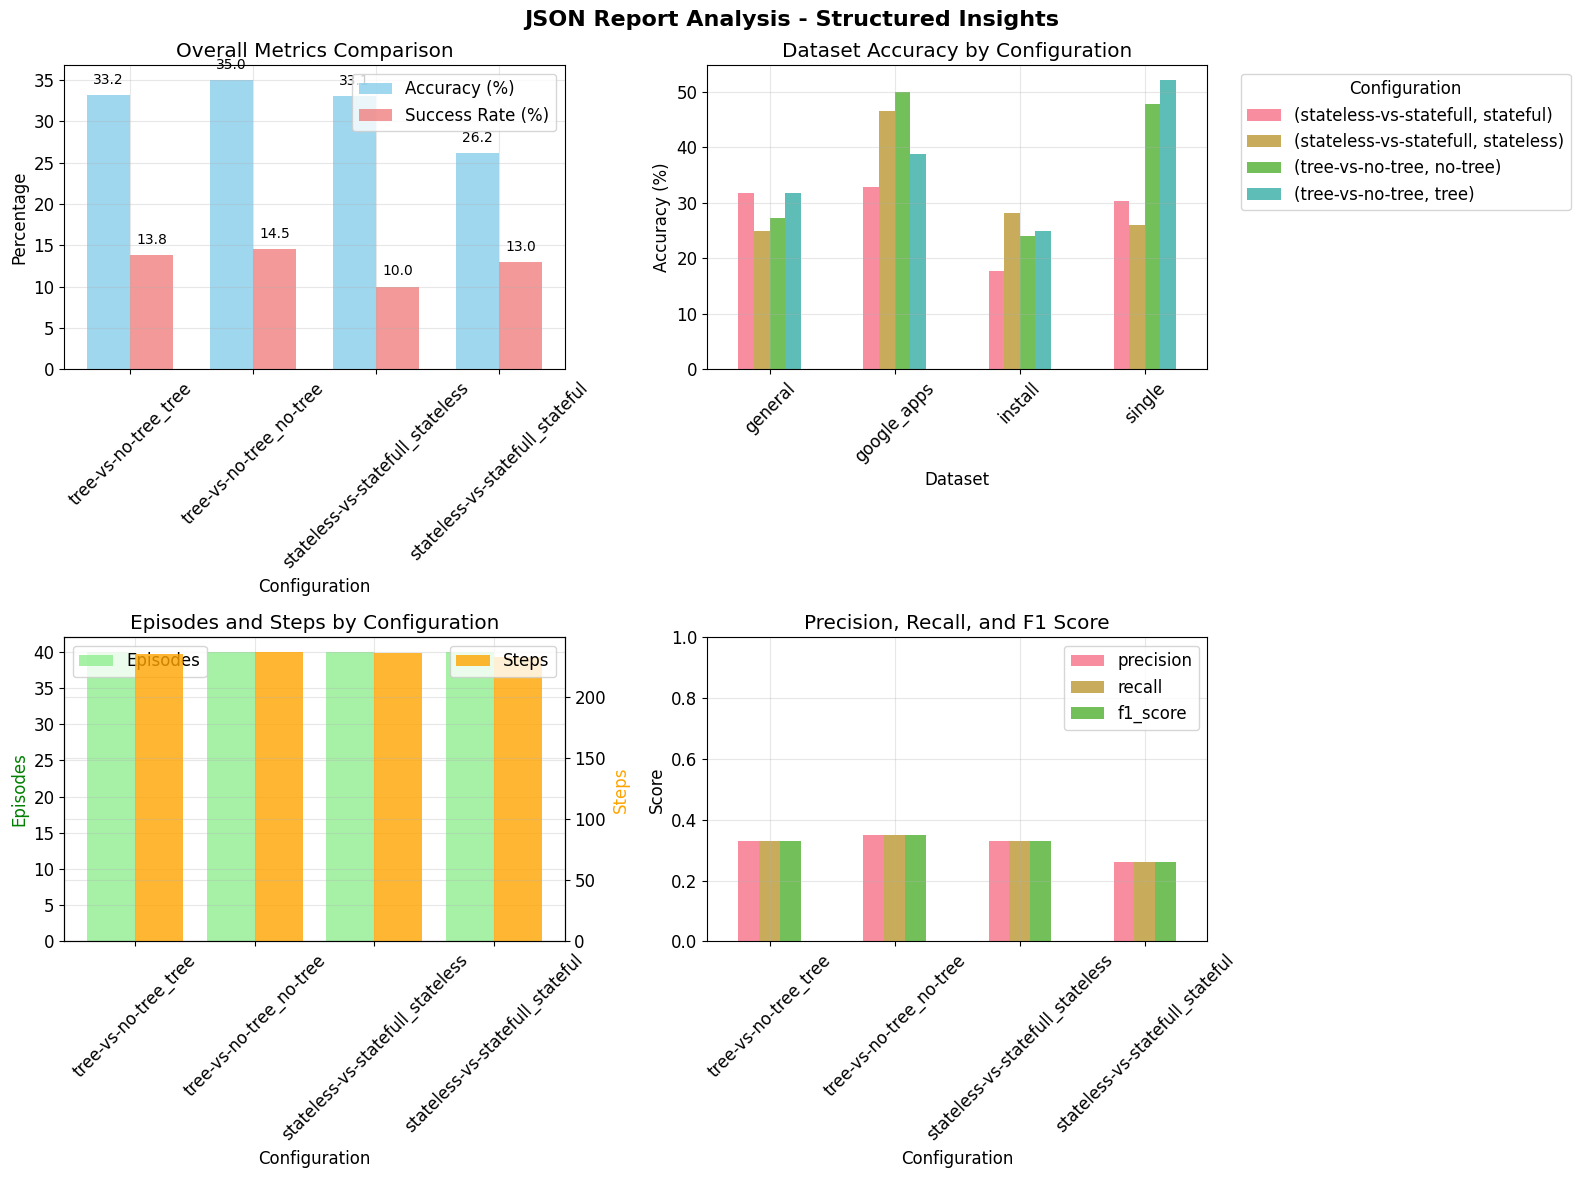


JSON REPORT SUMMARY

TREE-VS-NO-TREE_TREE:
  Overall Accuracy: 33.19%
  Success Rate: 13.80%
  F1 Score: 0.332
  Total Episodes: 40
  Total Steps: 235
  Dataset Performance:
    general: 31.8% accuracy
    google_apps: 38.9% accuracy
    install: 25.0% accuracy
    single: 52.2% accuracy

TREE-VS-NO-TREE_NO-TREE:
  Overall Accuracy: 35.02%
  Success Rate: 14.53%
  F1 Score: 0.350
  Total Episodes: 40
  Total Steps: 237
  Dataset Performance:
    general: 27.3% accuracy
    google_apps: 50.0% accuracy
    install: 24.0% accuracy
    single: 47.8% accuracy

STATELESS-VS-STATEFULL_STATELESS:
  Overall Accuracy: 33.05%
  Success Rate: 10.03%
  F1 Score: 0.331
  Total Episodes: 40
  Total Steps: 236
  Dataset Performance:
    general: 25.0% accuracy
    google_apps: 46.6% accuracy
    install: 28.1% accuracy
    single: 26.1% accuracy

STATELESS-VS-STATEFULL_STATEFUL:
  Overall Accuracy: 26.18%
  Success Rate: 12.99%
  F1 Score: 0.262
  Total Episodes: 40
  Total Steps: 233
  Dataset Perfo

In [9]:
# Load and analyze JSON reports
if json_files:
    print("Loading JSON reports...")
    
    all_reports = []
    
    for json_file in json_files:
        report = load_json_report(json_file)
        if report:
            # Extract run information from path
            path_parts = json_file.parts
            if 'stateless-vs-statefull' in path_parts:
                run_type = 'stateless-vs-statefull'
                if 'stateless' in path_parts:
                    run_config = 'stateless'
                elif 'statefull' in path_parts:
                    run_config = 'stateful'
            elif 'tree-vs-no-tree' in path_parts:
                run_type = 'tree-vs-no-tree'
                if 'tree' in path_parts:
                    run_config = 'tree'
                elif 'no-tree' in path_parts:
                    run_config = 'no-tree'
            else:
                run_type = 'unknown'
                run_config = 'unknown'
            
            # Add metadata
            report['run_type'] = run_type
            report['run_config'] = run_config
            report['file_path'] = str(json_file)
            
            all_reports.append(report)
    
    print(f"Loaded {len(all_reports)} JSON reports")
    
    if all_reports:
        # Create report analysis visualizations
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('JSON Report Analysis - Structured Insights', fontsize=16, fontweight='bold')
        
        # 1. Overall metrics comparison
        ax1 = axes[0, 0]
        report_metrics = []
        for report in all_reports:
            if 'overall_metrics' in report:
                metrics = report['overall_metrics'].copy()
                metrics['run_type'] = report['run_type']
                metrics['run_config'] = report['run_config']
                report_metrics.append(metrics)
        
        if report_metrics:
            metrics_df = pd.DataFrame(report_metrics)
            metrics_df['config_label'] = metrics_df['run_type'] + '_' + metrics_df['run_config']
            
            # Plot accuracy and success rate
            x_pos = np.arange(len(metrics_df))
            width = 0.35
            
            bars1 = ax1.bar(x_pos - width/2, metrics_df['accuracy'] * 100, width, 
                          label='Accuracy (%)', alpha=0.8, color='skyblue')
            bars2 = ax1.bar(x_pos + width/2, metrics_df['success_rate'], width,
                          label='Success Rate (%)', alpha=0.8, color='lightcoral')
            
            ax1.set_xlabel('Configuration')
            ax1.set_ylabel('Percentage')
            ax1.set_title('Overall Metrics Comparison')
            ax1.set_xticks(x_pos)
            ax1.set_xticklabels(metrics_df['config_label'], rotation=45)
            ax1.legend()
            
            # Add value labels
            for bars in [bars1, bars2]:
                for bar in bars:
                    height = bar.get_height()
                    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                            f'{height:.1f}', ha='center', va='bottom', fontsize=10)
        
        # 2. Dataset performance comparison from reports
        ax2 = axes[0, 1]
        dataset_metrics = []
        for report in all_reports:
            if 'dataset_metrics' in report:
                for dataset, metrics in report['dataset_metrics'].items():
                    dataset_metric = metrics.copy()
                    dataset_metric['dataset'] = dataset
                    dataset_metric['run_type'] = report['run_type']
                    dataset_metric['run_config'] = report['run_config']
                    dataset_metrics.append(dataset_metric)
        
        if dataset_metrics:
            dataset_df = pd.DataFrame(dataset_metrics)
            dataset_pivot = dataset_df.pivot_table(
                index='dataset', 
                columns=['run_type', 'run_config'], 
                values='accuracy',
                aggfunc='mean'
            ) * 100
            
            dataset_pivot.plot(kind='bar', ax=ax2, alpha=0.8)
            ax2.set_title('Dataset Accuracy by Configuration')
            ax2.set_xlabel('Dataset')
            ax2.set_ylabel('Accuracy (%)')
            ax2.legend(title='Configuration', bbox_to_anchor=(1.05, 1), loc='upper left')
            ax2.tick_params(axis='x', rotation=45)
        
        # 3. Episode and step counts
        ax3 = axes[1, 0]
        episode_data = []
        for report in all_reports:
            if 'overall_metrics' in report:
                episode_data.append({
                    'config': f"{report['run_type']}_{report['run_config']}",
                    'total_episodes': report['overall_metrics'].get('total_episodes', 0),
                    'total_steps': report['overall_metrics'].get('total_steps', 0)
                })
        
        if episode_data:
            episode_df = pd.DataFrame(episode_data)
            
            x_pos = np.arange(len(episode_df))
            ax3_twin = ax3.twinx()
            
            bars1 = ax3.bar(x_pos - 0.2, episode_df['total_episodes'], 0.4, 
                          label='Episodes', alpha=0.8, color='lightgreen')
            bars2 = ax3_twin.bar(x_pos + 0.2, episode_df['total_steps'], 0.4,
                               label='Steps', alpha=0.8, color='orange')
            
            ax3.set_xlabel('Configuration')
            ax3.set_ylabel('Episodes', color='green')
            ax3_twin.set_ylabel('Steps', color='orange')
            ax3.set_title('Episodes and Steps by Configuration')
            ax3.set_xticks(x_pos)
            ax3.set_xticklabels(episode_df['config'], rotation=45)
            
            # Add legends
            ax3.legend(loc='upper left')
            ax3_twin.legend(loc='upper right')
        
        # 4. F1 Score and Precision/Recall comparison
        ax4 = axes[1, 1]
        if report_metrics:
            performance_cols = ['precision', 'recall', 'f1_score']
            performance_data = metrics_df[performance_cols + ['config_label']].set_index('config_label')
            
            performance_data.plot(kind='bar', ax=ax4, alpha=0.8)
            ax4.set_title('Precision, Recall, and F1 Score')
            ax4.set_xlabel('Configuration')
            ax4.set_ylabel('Score')
            ax4.legend()
            ax4.tick_params(axis='x', rotation=45)
            ax4.set_ylim(0, 1)
        
        plt.tight_layout()
        plt.show()
        
        # Print detailed report summary
        print("\n" + "="*70)
        print("JSON REPORT SUMMARY")
        print("="*70)
        
        for report in all_reports:
            config_name = f"{report['run_type']}_{report['run_config']}"
            print(f"\n{config_name.upper()}:")
            
            if 'overall_metrics' in report:
                metrics = report['overall_metrics']
                print(f"  Overall Accuracy: {metrics.get('accuracy', 0)*100:.2f}%")
                print(f"  Success Rate: {metrics.get('success_rate', 0):.2f}%")
                print(f"  F1 Score: {metrics.get('f1_score', 0):.3f}")
                print(f"  Total Episodes: {metrics.get('total_episodes', 0)}")
                print(f"  Total Steps: {metrics.get('total_steps', 0)}")
            
            if 'dataset_metrics' in report:
                print(f"  Dataset Performance:")
                for dataset, dataset_metrics in report['dataset_metrics'].items():
                    print(f"    {dataset}: {dataset_metrics.get('accuracy', 0)*100:.1f}% accuracy")

else:
    print("No JSON report files found!")

## 8. Summary Visualizations - Complete Story Dashboard

Finally, let's create a comprehensive dashboard that tells the complete story of our experimental results.

Creating comprehensive summary dashboard...


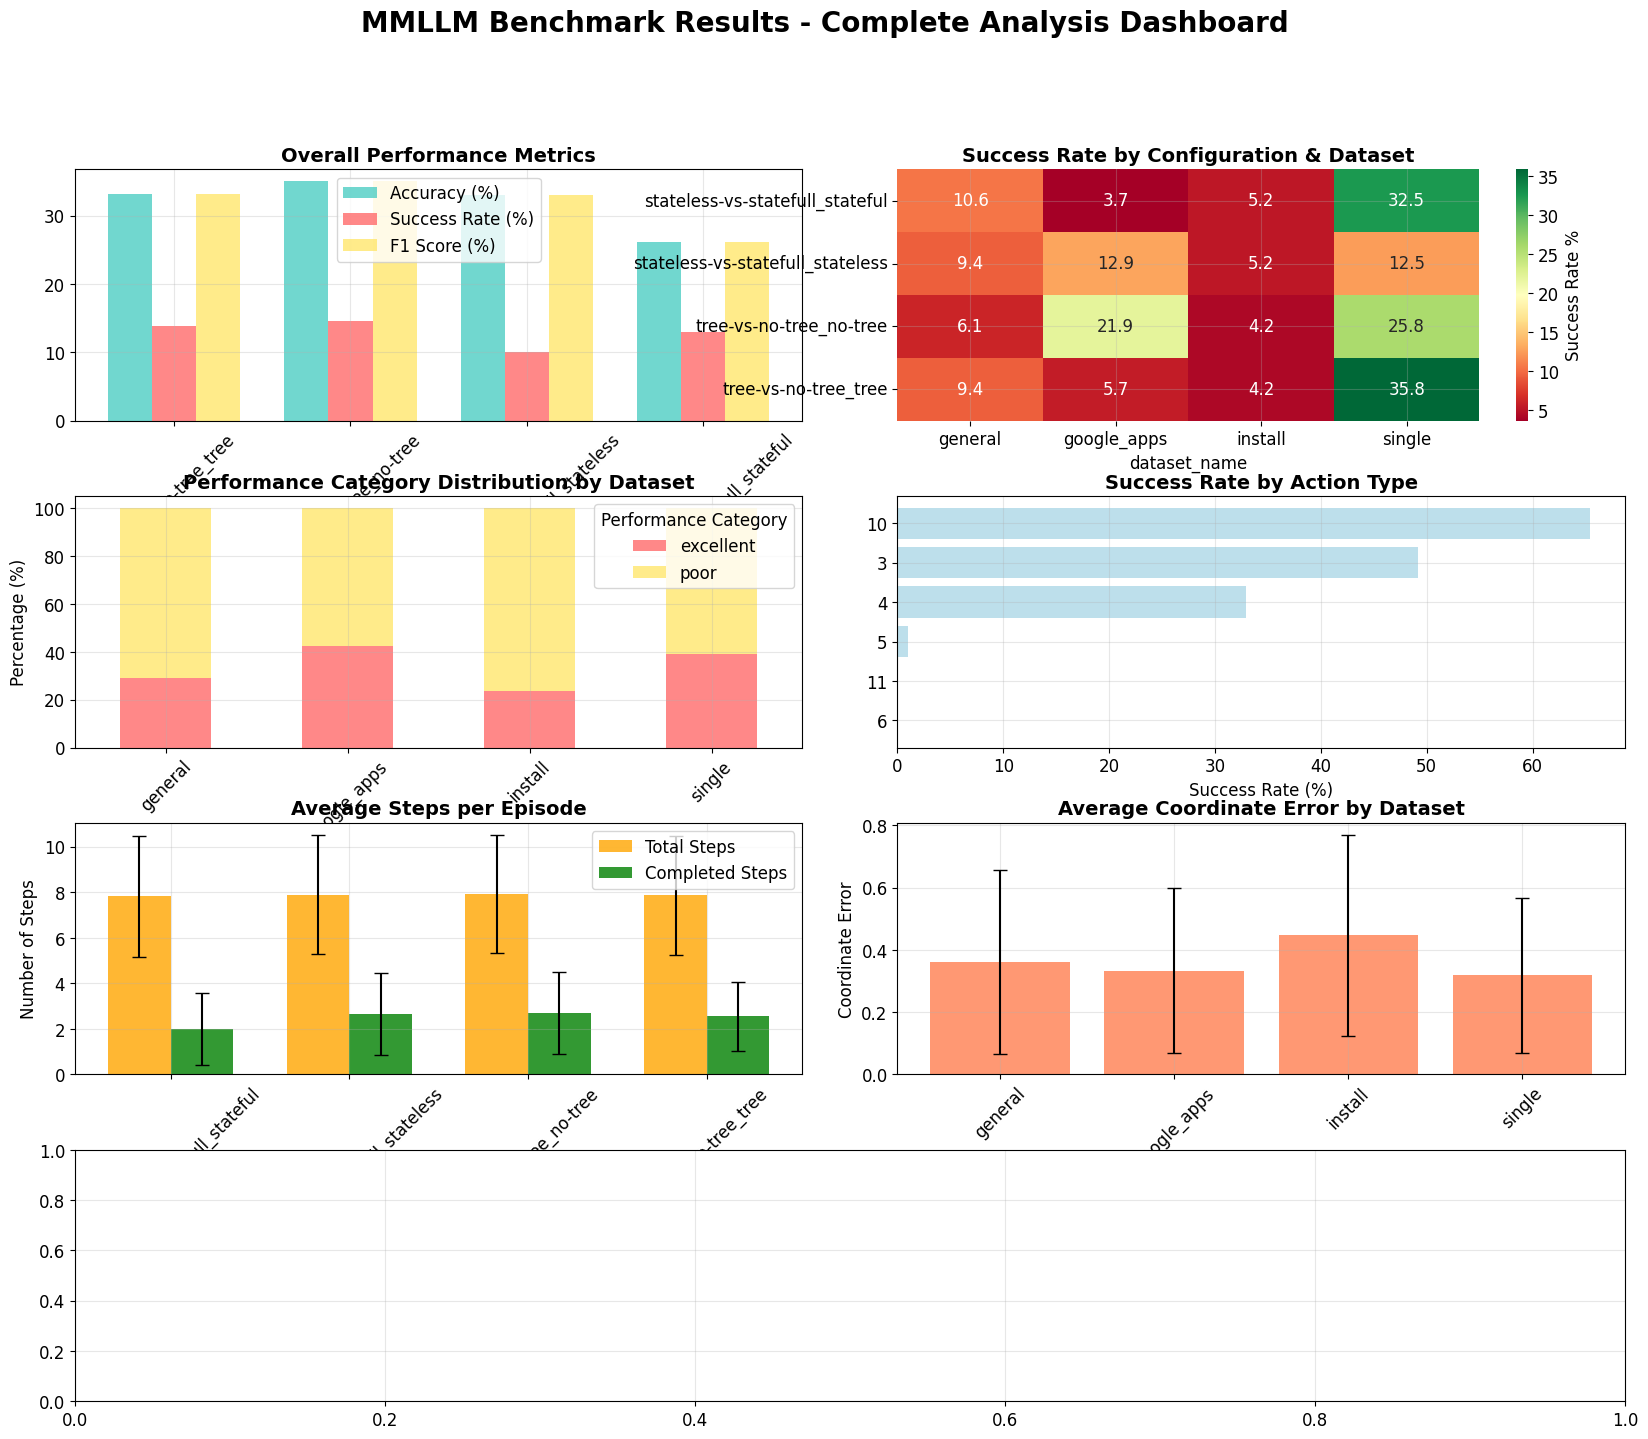

In [11]:
# Create comprehensive summary dashboard
if not combined_data.empty and all_reports:
    print("Creating comprehensive summary dashboard...")
    
    # Create a large dashboard figure
    fig = plt.figure(figsize=(20, 16))
    gs = fig.add_gridspec(4, 4, hspace=0.3, wspace=0.3)
    
    fig.suptitle('MMLLM Benchmark Results - Complete Analysis Dashboard', 
                fontsize=20, fontweight='bold', y=0.98)
    
    # 1. Overall Performance Comparison (Top Left)
    ax1 = fig.add_subplot(gs[0, 0:2])
    if report_metrics:
        metrics_df['config_label'] = metrics_df['run_type'] + '_' + metrics_df['run_config']
        
        x_pos = np.arange(len(metrics_df))
        width = 0.25
        
        bars1 = ax1.bar(x_pos - width, metrics_df['accuracy'] * 100, width, 
                       label='Accuracy (%)', alpha=0.8, color='#4ECDC4')
        bars2 = ax1.bar(x_pos, metrics_df['success_rate'], width,
                       label='Success Rate (%)', alpha=0.8, color='#FF6B6B')
        bars3 = ax1.bar(x_pos + width, metrics_df['f1_score'] * 100, width,
                       label='F1 Score (%)', alpha=0.8, color='#FFE66D')
        
        ax1.set_title('Overall Performance Metrics', fontsize=14, fontweight='bold')
        ax1.set_xticks(x_pos)
        ax1.set_xticklabels(metrics_df['config_label'], rotation=45)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
    
    # 2. Dataset Performance Heatmap (Top Right)
    ax2 = fig.add_subplot(gs[0, 2:4])
    if not combined_data.empty:
        episode_metrics = combined_data.groupby(['run_type', 'run_config', 'dataset_name', 'episode_id']).agg({
            'episode_success_rate': 'first'
        }).reset_index()
        
        heatmap_data = episode_metrics.groupby(['run_type', 'run_config', 'dataset_name'])['episode_success_rate'].mean().unstack(level='dataset_name')
        heatmap_data.index = [f"{rt}_{rc}" for rt, rc in heatmap_data.index]
        
        sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax2, 
                   cbar_kws={'label': 'Success Rate %'})
        ax2.set_title('Success Rate by Configuration & Dataset', fontsize=14, fontweight='bold')
    
    # 3. Failure Pattern Analysis (Middle Left)
    ax3 = fig.add_subplot(gs[1, 0:2])
    if not combined_data.empty:
        failure_data = combined_data.groupby(['dataset_name', 'performance_category']).size().unstack(fill_value=0)
        failure_data_pct = failure_data.div(failure_data.sum(axis=1), axis=0) * 100
        
        failure_data_pct.plot(kind='bar', stacked=True, ax=ax3, 
                             color=['#FF6B6B', '#FFE66D', '#4ECDC4'], alpha=0.8)
        ax3.set_title('Performance Category Distribution by Dataset', fontsize=14, fontweight='bold')
        ax3.set_xlabel('Dataset')
        ax3.set_ylabel('Percentage (%)')
        ax3.legend(title='Performance Category')
        ax3.tick_params(axis='x', rotation=45)
    
    # 4. Action Type Success Rates (Middle Right)
    ax4 = fig.add_subplot(gs[1, 2:4])
    if not combined_data.empty:
        action_success = combined_data.groupby('model_action_type').agg({
            'step_action_match': ['count', 'sum']
        })
        action_success.columns = ['total', 'successful']
        action_success['success_rate'] = (action_success['successful'] / action_success['total']) * 100
        action_success = action_success.sort_values('success_rate', ascending=True)
        
        bars = ax4.barh(range(len(action_success)), action_success['success_rate'], 
                       color='lightblue', alpha=0.8)
        ax4.set_yticks(range(len(action_success)))
        ax4.set_yticklabels(action_success.index)
        ax4.set_xlabel('Success Rate (%)')
        ax4.set_title('Success Rate by Action Type', fontsize=14, fontweight='bold')
        ax4.grid(True, alpha=0.3)
    
    # 5. Episode Statistics (Bottom Left)
    ax5 = fig.add_subplot(gs[2, 0:2])
    if not combined_data.empty:
        episode_stats = combined_data.groupby(['run_type', 'run_config']).agg({
            'episode_total_steps': ['mean', 'std'],
            'episode_steps_completed': ['mean', 'std']
        })
        episode_stats.columns = ['_'.join(col).strip() for col in episode_stats.columns]
        episode_stats.index = [f"{rt}_{rc}" for rt, rc in episode_stats.index]
        
        x_pos = np.arange(len(episode_stats))
        width = 0.35
        
        bars1 = ax5.bar(x_pos - width/2, episode_stats['episode_total_steps_mean'], width,
                       yerr=episode_stats['episode_total_steps_std'], capsize=5,
                       label='Total Steps', alpha=0.8, color='orange')
        bars2 = ax5.bar(x_pos + width/2, episode_stats['episode_steps_completed_mean'], width,
                       yerr=episode_stats['episode_steps_completed_std'], capsize=5,
                       label='Completed Steps', alpha=0.8, color='green')
        
        ax5.set_title('Average Steps per Episode', fontsize=14, fontweight='bold')
        ax5.set_xticks(x_pos)
        ax5.set_xticklabels(episode_stats.index, rotation=45)
        ax5.set_ylabel('Number of Steps')
        ax5.legend()
        ax5.grid(True, alpha=0.3)
    
    # 6. Coordinate Error Analysis (Bottom Right)
    ax6 = fig.add_subplot(gs[2, 2:4])
    if not combined_data.empty:
        coord_data = combined_data[combined_data['coordinate_error'].notna()]
        if not coord_data.empty:
            coord_by_dataset = coord_data.groupby('dataset_name')['coordinate_error'].agg(['mean', 'std'])
            
            bars = ax6.bar(coord_by_dataset.index, coord_by_dataset['mean'], 
                          yerr=coord_by_dataset['std'], capsize=5,
                          color='coral', alpha=0.8)
            ax6.set_title('Average Coordinate Error by Dataset', fontsize=14, fontweight='bold')
            ax6.set_ylabel('Coordinate Error')
            ax6.set_xlabel('Dataset')
            ax6.tick_params(axis='x', rotation=45)
            ax6.grid(True, alpha=0.3)
        else:
            ax6.text(0.5, 0.5, 'No coordinate data available', 
                    ha='center', va='center', transform=ax6.transAxes, fontsize=12)
    
    # 7. Key Statistics Summary (Bottom Full Width)
    ax7 = fig.add_subplot(gs[3, :])